In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\sriha\Downloads\sample (1).csv')


In [2]:
import pandas as pd
df = pd.read_csv("C:/Users/sriha/Downloads/sample.csv")
df["total_amount"] = df["monthly_emi"] * df["tenure_months"]
df["tenure_years"] = df["tenure_months"] / 12
avg_total = df.groupby("risk_flag")["total_amount"].mean()
print("Total Amount Added:")
print(df[["customer_name", "total_amount"]])
print("\nTenure in Years:")
print(df[["customer_name", "tenure_years"]])
print("\nAverage Total Contract Amount per Risk flag:")
print(avg_total)

Total Amount Added:
   customer_name  total_amount
0    Rahul Mehta        888000
1      Anita Rao        792000
2   James Wilson        870000
3     Meena Iyer        504000
4    Arjun Patel       1980000
5      Sana Khan        594000
6    Vikram Shah        702000
7     Neha Singh       1224000
8      David Roy       2562000
9    Kiran Kumar        555000
10   Pratima Das        633600
11     Imran Ali       1029000

Tenure in Years:
   customer_name  tenure_years
0    Rahul Mehta           4.0
1      Anita Rao           3.0
2   James Wilson           5.0
3     Meena Iyer           2.0
4    Arjun Patel           6.0
5      Sana Khan           3.0
6    Vikram Shah           3.0
7     Neha Singh           4.0
8      David Roy           7.0
9    Kiran Kumar           2.5
10   Pratima Das           4.0
11     Imran Ali           3.5

Average Total Contract Amount per Risk flag:
risk_flag
high      1407000.0
low        683000.0
medium     812400.0
Name: total_amount, dtype: float64


In [3]:
keywords = ["fee", "penalty", "late", "extra"]
def detect_hidden_charges(text):
    text = str(text).lower()
    for word in keywords:
        if word in text:
            return 1
    return 0
df["hidden_charges_flag"] = df["clause_summary"].apply(detect_hidden_charges)
df[["customer_name", "clause_summary", "hidden_charges_flag"]]

,customer_name,clause_summary,hidden_charges_flag
0,Rahul Mehta,Prepayment allowed only after 24 months with 5...,1
1,Anita Rao,Lessee must pay for all maintenance and insurance,0
2,James Wilson,Late payment fee of 3% per month on outstandin...,1
3,Meena Iyer,"Excess mileage charge of ₹12 per km over 15,00...",0
4,Arjun Patel,Floating interest rate linked to lender's inte...,0
5,Sana Khan,Early termination fee equal to 6 months of EMI,1
6,Vikram Shah,No foreclosure charges after 12 months,0
7,Neha Singh,Battery warranty covered only for 24 months or...,0
8,David Roy,Mandatory bundled insurance from lender at non...,0
9,Kiran Kumar,"Security deposit of 3 EMIs, refundable at end ...",0


In [4]:
from collections import Counter
high_risk_text = " ".join(df[df["risk_flag"]=="high"]["clause_summary"].astype(str).tolist()).lower()
words = high_risk_text.split()
word_freq = Counter(words)
word_freq.most_common(10)

[('fee', 2),
 ('of', 2),
 ('to', 2),
 ('late', 1),
 ('payment', 1),
 ('3%', 1),
 ('per', 1),
 ('month', 1),
 ('on', 1),
 ('outstanding', 1)]

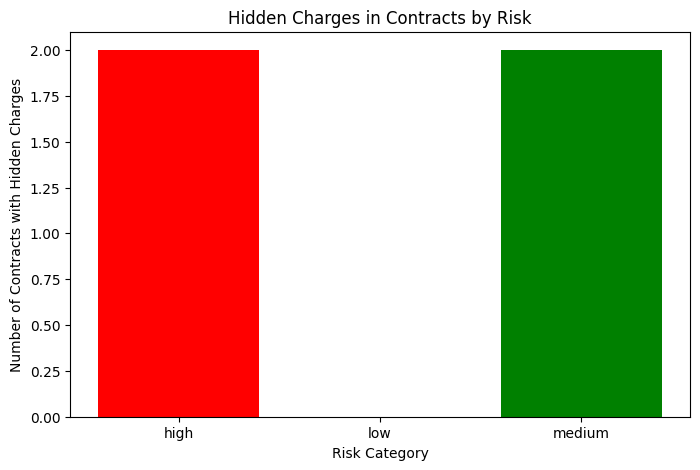

In [5]:
import matplotlib.pyplot as plt
hidden_counts = df.groupby("risk_flag")["hidden_charges_flag"].sum()
plt.figure(figsize=(8,5))
plt.bar(hidden_counts.index, hidden_counts.values, color=["red","orange","green"])
plt.xlabel("Risk Category")
plt.ylabel("Number of Contracts with Hidden Charges")
plt.title("Hidden Charges in Contracts by Risk")
plt.show()